In [9]:
! pip install lightgbm --upgrade optuna

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.1 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.1 MB ? eta -:--:--
   --------- ------------------------------ 0.5/2.1 MB 587.1 kB/s eta 0:00:03
   --------- ------------------------------ 0.5/2.1 MB 587.1 kB/s eta 0:00:03
   -------------- ------------------------- 0.8/2.1 MB 606.7 kB/s eta 0:00:03
   -------------- ------------------------- 0.8/2.1 MB 606.7 kB/s eta 0:00:03
   ------------------- -------------------- 1.0/2.1 MB 611.4 kB/s eta 0:00:02
   ------------------- -------------------- 1.0/2.1 MB 611.4 kB/s eta 0:00:02
   ------------------------ --------------- 1.3/2.1 MB 622.2 kB/s eta 0:00:02
   ------------------------ ---

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


# Phase 1 — Data Cleaning
1. Drop identifier columns (`Mixture` and `Specimen`).
2. Drop rows with missing `Fiber Type` (~3 rows).
3. Compute the 1 missing `L/D` value using `Length / Diameter`.
4. Apply One-Hot Encoding to `Fiber Type`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, KFold, cross_validate, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from xgboost import XGBRegressor

In [14]:
df = pd.read_excel("Tension.xlsx")
df = df.drop(columns=['Mixture', 'Specimen','Shape Factor', 'L/D', 'RI', 'W/C', 'W/B', 'C/B'])
df = df.dropna(subset=['Fiber Type'])
df = df.reset_index(drop=True)
df_original = df.copy()
df = pd.get_dummies(df, columns=['Fiber Type'], drop_first=False)
print(f"Cleaned df shape       : {df.shape}")
print(f"Index range: {df.index.min()} to {df.index.max()}")

Cleaned df shape       : (503, 38)
Index range: 0 to 502


In [3]:
X = df.drop(columns=['Second Stress', 'Second Strain'])
y_stress    = df['Second Stress']
y_strain    = df['Second Strain']
y_strain_log = np.log1p(df['Second Strain']) 
print(f"Feature matrix shape: {X.shape}")
print(f"Stress range : {y_stress.min():.3f} – {y_stress.max():.3f}")
print(f"Strain range : {y_strain.min():.4f} – {y_strain.max():.4f}")
print(f"Strain (log) : {y_strain_log.min():.4f} – {y_strain_log.max():.4f}")

Feature matrix shape: (503, 42)
Stress range : 0.862 – 11.060
Strain range : 0.0001 – 0.1346
Strain (log) : 0.0001 – 0.1263


In [15]:
X_train, X_test, \
y_stress_train, y_stress_test, \
y_strain_train, y_strain_test = train_test_split(
    X, y_stress, y_strain_log,
    test_size=0.20,
    random_state=42
)
scaler = StandardScaler()

ValueError: Found input variables with inconsistent numbers of samples: [402, 503, 503]

In [16]:
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X.columns,
    index=X_test.index
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

print(f"Training set : {X_train_scaled.shape[0]} rows")
print(f"Testing set  : {X_test_scaled.shape[0]} rows")

Training set : 402 rows
Testing set  : 101 rows


In [17]:
models = {
    "Random Forest" : RandomForestRegressor(random_state=42),
    "XGBoost"       : XGBRegressor(random_state=42, objective='reg:squarederror'),
    "SVR"           : SVR(),
    "Poly Ridge"    : make_pipeline(PolynomialFeatures(degree=2), Ridge(alpha=10))
}

def evaluate_baselines(X, y, target_name, cv):
    results = []
    for name, model in models.items():
        cv_scores = cross_validate(
            model, X, y, cv=cv,
            scoring=('r2', 'neg_root_mean_squared_error')
        )
        results.append({
            "Model"   : name,
            "Target"  : target_name,
            "CV R2"   : round(cv_scores['test_r2'].mean(), 4),
            "CV RMSE" : round(-cv_scores['test_neg_root_mean_squared_error'].mean(), 6)
        })
    return pd.DataFrame(results)

baseline_stress = evaluate_baselines(X_train_scaled, y_stress_train, "Second Stress",kf)
baseline_strain = evaluate_baselines(X_train_scaled, y_strain_train, "Second Strain (log)", kf)  
baseline_results = pd.concat([baseline_stress, baseline_strain], ignore_index=True)
print("\n── Baseline Results ──")
display(baseline_results.sort_values(by=["Target", "CV R2"], ascending=[True, False]))


── Baseline Results ──


,Model,Target,CV R2,CV RMSE
4,Random Forest,Second Strain (log),0.4680,0.013282
5,XGBoost,Second Strain (log),0.4505,0.013510
7,Poly Ridge,Second Strain (log),0.2822,0.015619
6,SVR,Second Strain (log),-2.8917,0.035980
1,XGBoost,Second Stress,0.8286,0.626072
0,Random Forest,Second Stress,0.8197,0.647255
2,SVR,Second Stress,0.6160,0.962406
3,Poly Ridge,Second Stress,0.3965,1.176141


In [18]:
train_indices       = X_train.index
valid_train_indices = train_indices[train_indices.isin(df_original.index)]

results_by_fiber = []

for fiber in df_original['Fiber Type'].dropna().unique():
    fiber_mask    = df_original.loc[valid_train_indices, 'Fiber Type'] == fiber
    fiber_indices = valid_train_indices[fiber_mask]

    if len(fiber_indices) < 15:
        print(f"  Skipping '{fiber}' — only {len(fiber_indices)} samples")
        continue

    X_f = X_train_scaled.loc[fiber_indices]
    y_f = y_strain_train.loc[fiber_indices]

    cv_folds = min(3, len(X_f) // 5)
    if cv_folds < 2:
        continue

    model  = RandomForestRegressor(random_state=42)
    scores = cross_val_score(model, X_f, y_f, cv=cv_folds, scoring='r2')

    results_by_fiber.append({
        'Fiber Type'   : fiber,
        'N Samples'    : len(fiber_indices),
        'CV R2 Strain' : round(scores.mean(), 4)
    })

fiber_results = (
    pd.DataFrame(results_by_fiber)
    .sort_values('CV R2 Strain', ascending=False)
    .reset_index(drop=True)
)
print("\n── Per-Fiber Strain R² ──")
display(fiber_results)

  Skipping 'Polyethylene' — only 12 samples
  Skipping 'REC-15 PVA Fibers' — only 8 samples
  Skipping 'Steel Hook' — only 1 samples
  Skipping 'Steel Twisted' — only 3 samples
  Skipping 'Unoiled PVA Fiber' — only 3 samples
  Skipping 'Oiled PVA Fiber' — only 3 samples
  Skipping 'REC 15' — only 2 samples
  Skipping 'BHL' — only 10 samples
  Skipping 'REC 16' — only 1 samples
  Skipping 'REC 17' — only 1 samples
  Skipping 'REC 18' — only 0 samples
  Skipping 'REC 19' — only 1 samples
  Skipping 'PVA Fiber + SMA' — only 1 samples
  Skipping 'PVA + Steel Fiber' — only 2 samples
  Skipping 'PVA Fiber Type K' — only 2 samples
  Skipping 'Kuraray PVA Fiber' — only 7 samples
  Skipping 'Chinese PVA Fiber' — only 8 samples

── Per-Fiber Strain R² ──


,Fiber Type,N Samples,CV R2 Strain
0,PVA Fiber Type C,15,0.6827
1,PE Fiber,17,0.3141
2,PVA Fiber,218,0.1474
3,PP Fiber,35,0.0900
4,WW,22,-0.4040
5,HTTP Fiber,30,-3.9691


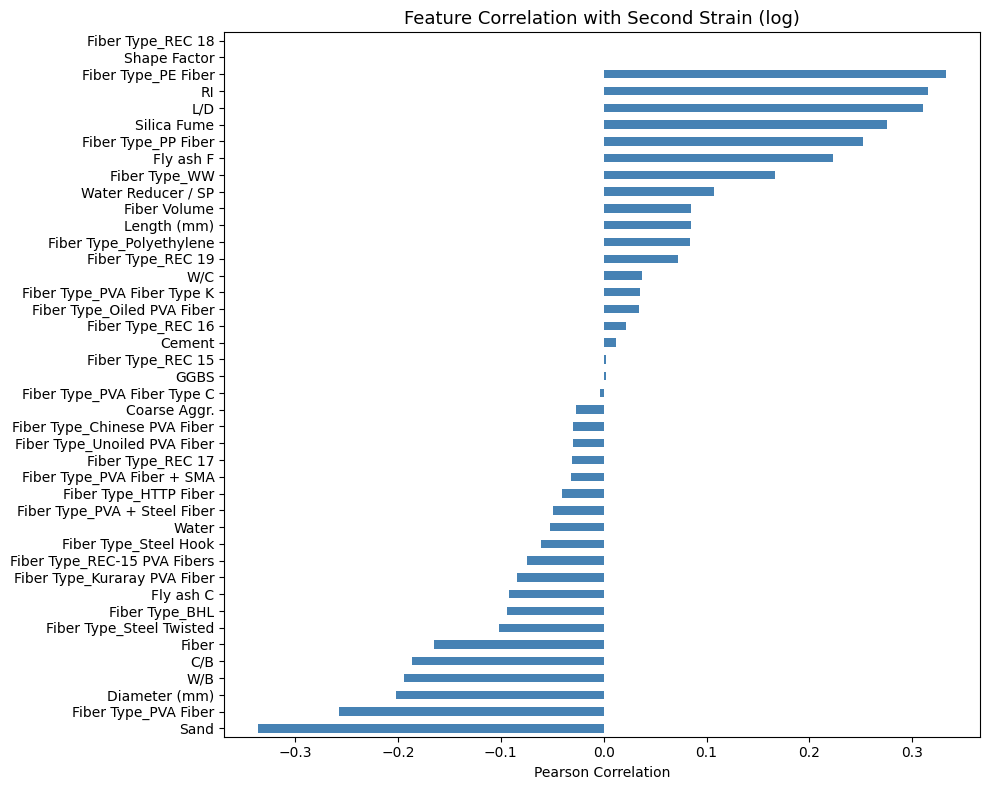

Saved: feature_correlation_strain.png


In [ ]:
correlations = X_train.corrwith(y_strain_train).sort_values()
plt.figure(figsize=(10, 8))
correlations.plot(kind='barh', color='steelblue')
plt.title('Feature Correlation with Second Strain (log)', fontsize=13)
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.savefig('feature_correlation_strain.png', dpi=150)
plt.show()
print("Saved: feature_correlation_strain.png")




In [10]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # suppress noise

from sklearn.model_selection import cross_val_score

In [12]:
def objective_rf(trial, X, y):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 1000),
        'max_depth'        : trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf' : trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features'     : trial.suggest_float('max_features', 0.3, 1.0),
        'random_state'     : 42
    }
    model  = RandomForestRegressor(**params)
    scores = cross_val_score(model, X, y, cv=kf, scoring='r2')
    return scores.mean()

def objective_xgb(trial, X, y):
    params = {
        'n_estimators'      : trial.suggest_int('n_estimators', 100, 1000),
        'max_depth'         : trial.suggest_int('max_depth', 3, 10),
        'learning_rate'     : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'         : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha'         : trial.suggest_float('reg_alpha', 1e-5, 10, log=True),
        'reg_lambda'        : trial.suggest_float('reg_lambda', 1e-5, 10, log=True),
        'objective'         : 'reg:squarederror',
        'random_state'      : 42,
        'verbosity'         : 0
    }
    model  = XGBRegressor(**params)
    scores = cross_val_score(model, X, y, cv=kf, scoring='r2')
    return scores.mean()

N_TRIALS = 100  

tuning_jobs = [
    ("RF",  "Second Stress",       objective_rf,  X_train_scaled, y_stress_train),
    ("XGB", "Second Stress",       objective_xgb, X_train_scaled, y_stress_train),
    ("RF",  "Second Strain (log)", objective_rf,  X_train_scaled, y_strain_train),
    ("XGB", "Second Strain (log)", objective_xgb, X_train_scaled, y_strain_train),
]

best_params  = {}
tuning_summary = []

for model_name, target_name, objective, X, y in tuning_jobs:
    key = f"{model_name}_{target_name}"
    print(f"Tuning {model_name} → {target_name} ...")

    study = optuna.create_study(direction='maximize')
    study.optimize(lambda trial: objective(trial, X, y), n_trials=N_TRIALS)

    best_params[key] = study.best_params
    tuning_summary.append({
        "Model"       : model_name,
        "Target"      : target_name,
        "Best CV R2"  : round(study.best_value, 4),
        "Best Params" : study.best_params
    })
    print(f"  ✅ Done — Best R²: {study.best_value:.4f}")

tuning_df = pd.DataFrame(tuning_summary)[["Model", "Target", "Best CV R2"]]
print("\n── Tuning Results ──")
display(tuning_df)

for key, params in best_params.items():
    print(f"\n{key}:\n  {params}")

Tuning RF → Second Stress ...
  ✅ Done — Best R²: 0.8309
Tuning XGB → Second Stress ...
  ✅ Done — Best R²: 0.8388
Tuning RF → Second Strain (log) ...
  ✅ Done — Best R²: 0.4888
Tuning XGB → Second Strain (log) ...
  ✅ Done — Best R²: 0.4976

── Tuning Results ──


,Model,Target,Best CV R2
0,RF,Second Stress,0.8309
1,XGB,Second Stress,0.8388
2,RF,Second Strain (log),0.4888
3,XGB,Second Strain (log),0.4976



RF_Second Stress:
  {'n_estimators': 702, 'max_depth': 12, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.33260071595733587}

XGB_Second Stress:
  {'n_estimators': 390, 'max_depth': 4, 'learning_rate': 0.033768633578761385, 'subsample': 0.8568305397627602, 'colsample_bytree': 0.9945864929256946, 'reg_alpha': 0.012106520884768686, 'reg_lambda': 2.8751649591024333}

RF_Second Strain (log):
  {'n_estimators': 213, 'max_depth': 7, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.5717279045296773}

XGB_Second Strain (log):
  {'n_estimators': 544, 'max_depth': 4, 'learning_rate': 0.010024017480205021, 'subsample': 0.8982543349173411, 'colsample_bytree': 0.878852874183139, 'reg_alpha': 0.0011456488968821876, 'reg_lambda': 0.019936807581377454}


In [13]:
# ── CELL: Stacking Ensemble ───────────────────────────────────
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ── Build tuned base models ───────────────────────────────────
rf_stress  = RandomForestRegressor(**best_params['RF_Second Stress'],  random_state=42, n_jobs=-1)
xgb_stress = XGBRegressor(**best_params['XGB_Second Stress'],          random_state=42, verbosity=0)

rf_strain  = RandomForestRegressor(**best_params['RF_Second Strain (log)'],  random_state=42, n_jobs=-1)
xgb_strain = XGBRegressor(**best_params['XGB_Second Strain (log)'],          random_state=42, verbosity=0)

# ── Stacking — Stress ─────────────────────────────────────────
stack_stress = StackingRegressor(
    estimators=[('rf', rf_stress), ('xgb', xgb_stress)],
    final_estimator=Ridge(alpha=1.0),
    cv=5,
    n_jobs=-1
)

# ── Stacking — Strain ─────────────────────────────────────────
stack_strain = StackingRegressor(
    estimators=[('rf', rf_strain), ('xgb', xgb_strain)],
    final_estimator=Ridge(alpha=1.0),
    cv=5,
    n_jobs=-1
)

# ── Train on full training set ────────────────────────────────
print("Training stacking models...")
stack_stress.fit(X_train_scaled, y_stress_train)
stack_strain.fit(X_train_scaled, y_strain_train)
print("✅ Done")

# ── Evaluate on TEST SET (first time touching test data) ──────
def evaluate_on_test(model, X_test, y_test, target_name, is_log=False):
    pred = model.predict(X_test)
    
    if is_log:
        pred   = np.expm1(pred)       # reverse log transform
        y_test = np.expm1(y_test)     # reverse log transform on actuals too
    
    r2   = r2_score(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae  = mean_absolute_error(y_test, pred)
    
    print(f"\n── {target_name} ──")
    print(f"  R²   : {r2:.4f}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    
    return {"Target": target_name, "R2": round(r2,4), 
            "RMSE": round(rmse,4), "MAE": round(mae,4)}, pred

print("\n════ FINAL TEST SET RESULTS ════")
stress_metrics, stress_preds = evaluate_on_test(
    stack_stress, X_test_scaled, y_stress_test, "Second Stress", is_log=False)

strain_metrics, strain_preds = evaluate_on_test(
    stack_strain, X_test_scaled, y_strain_test, "Second Strain", is_log=True)

# ── Final summary table ───────────────────────────────────────
final_results = pd.DataFrame([stress_metrics, strain_metrics])
print("\n── Final Results Table ──")
display(final_results)

Training stacking models...
✅ Done

════ FINAL TEST SET RESULTS ════

── Second Stress ──
  R²   : 0.8731
  RMSE : 0.6590
  MAE  : 0.4680

── Second Strain ──
  R²   : 0.1544
  RMSE : 0.0217
  MAE  : 0.0156

── Final Results Table ──


,Target,R2,RMSE,MAE
0,Second Stress,0.8731,0.6590,0.4680
1,Second Strain,0.1544,0.0217,0.0156
